# EV Car Prices

This assignment focuses on car prices. The data ('car_prices.xlsx') is a pre-processed version of original data scraped from bilbasen.dk by previous MAL1 students. The dataset contains 16 columns:

- **Price (DKK)**: The current listed price of the vehicle in Danish Kroner.
- **Model Year**: The manufacturing year of the vehicle.
- **Mileage (km)**: The total kilometres driven by the vehicle (odometer reading).
- **Electric Range (km)**: The estimated maximum driving range on a full charge.
- **Battery Capacity (kWh)**: The total capacity of the vehicle's battery in kilowatt-hours.
- **Energy Consumption (Wh/km)**: The vehicle's energy consumption in watt-hours per kilometre.
- **Annual Road Tax (DKK)**: The annual road tax cost in Danish Kroner.
- **Horsepower (bhp)**: The vehicle's horsepower (brake horsepower).
- **0-100 km/h (s)**: The time (in seconds) for the car to accelerate from 0 to 100 km/h.
- **Top Speed (km/h)**: The maximum speed the vehicle can achieve.
- **Towing Capacity (kg)**: The maximum weight the vehicle can tow.
- **Original Price (DKK)**: The price of the vehicle when first sold as new.
- **Number of Doors**: The total number of doors on the vehicle.
- **Rear-Wheel Drive**: A binary indicator (1 = Yes, 0 = No) for rear-wheel drive.
- **All-Wheel Drive (AWD)**: A binary indicator (1 = Yes, 0 = No) for all-wheel drive.
- **Front-Wheel Drive**: A binary indicator (1 = Yes, 0 = No) for front-wheel drive.

The first one, **Price**, is the response variable.

The **objective** of this assignment is:
1. Understand how linear algebra is used in Machine Learning, specifically for correlations and regression
2. Learn how to perform multiple linear regression, ridge regression, lasso regression and elastic net
3. Learn how to assess regression models

Please solve the tasks using this notebook as you template, i.e. insert code blocks and markdown block to this notebook and hand it in. Please use 42 as your random seed.


## Import data
 - Import the dataset 
 - Split the data in a training set and test set - make sure you extract the response variable
 - Remember to use the data appropriately; in the tasks below, we do not explicitly state when to use train and test - but in order to compare the models, you must use the same dataset for training and testing in all models.
 - Output: When you are done with this, you should have the following sets: `X` (the original dataset), `X_train`, `X_test`, `y_train`, `y_test`

In [ ]:
# Code block for important and creating data sets. Add more code blocks if needed.
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_excel('car_prices.xlsx')

y = df['Price (DKK)']
X = df.drop('Price (DKK)', axis=1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)
print(f"\nTraining set - Features: {X_train.shape}, Target: {y_train.shape}")
print(f"Test set - Features: {X_test.shape}, Target: {y_test.shape}")




Training set - Features: (4358, 15), Target: (4358,)
Test set - Features: (1868, 15), Target: (1868,)


## Part 1: Linear Algebra
In this assignment, you have to solve all problems using linear algebra concepts. You are free to use SymPy or NumPy - though NumPy is **significantly** more efficient computationally than SymPy since NumPy is optimized for numerical computations with floating-point arithmetic. Since linear regression is purely numerical, NumPy is the better choice.


### Task 1: Regression



Linear regression finds the best-fitting line (or hyperplane) by solving for the **coefficient vector** $\mathbf{B}$ that minimizes the squared error:

$$
\mathbf{B} = (\mathbf{X}^T \mathbf{X})^{-1} \mathbf{X}^T \mathbf{y}
$$

where:
- $\mathbf{X}$ is the **design matrix**, including a column of ones for the intercept.
- $\mathbf{y}$ is the **response variable** (target values).
- $\mathbf{B}$ contains the **regression coefficients**.

**Explanation of Each Step**
1. **Construct the matrix $X$**:
   - Each **row** represents a data point.
   - Each **column** represents a feature.

2. **Solve for $\mathbf{B}$ using the normal equation**:
   - Compute $X^T X$ (feature correlation).
   - Compute $X^T y$ (cross-product with the target variable).
   - Compute the **inverse of $X^T X$** and multiply by $X^T y$ to get $\mathbf{B}$.

3. **Interpret the results**:
   - The remaining values are the **coefficients for each feature**.



In [59]:
# Use this for Task 3. Add more code blocks if needed.


X_train_with_intercept = np.column_stack([np.ones(X_train.shape[0]), X_train])
X_test_with_intercept = np.column_stack([np.ones(X_test.shape[0]), X_test])

print(f"Design matrix shape (with intercept): {X_train_with_intercept.shape}")

X_T = X_train.T
# Calculate the transpose of X and the dot product of X^T * X
XtX = X_T @ X_train

Xty = X_train.T @ y_train

print(f"X^T * X shape: {XtX.shape}")

XtX_inv = np.linalg.inv(XtX)

# Calculate the coefficients
B = XtX_inv @ Xty

print(B)

feature_names = X_train.columns
for i, (feature, coef) in enumerate(zip(feature_names, B[1:]), 1):
    print(f"{feature}: {coef:.4f}")


Design matrix shape (with intercept): (4358, 16)
X^T * X shape: (15, 15)
[ 1.83283615e+04 -6.23213494e-01  1.83569652e+01  6.67219411e+02
 -7.27182294e+01 -3.21133291e+02  3.04074793e+01  6.92801405e+03
  2.14934200e+02  1.92902695e+01  7.39106568e-01  2.26100023e+03
 -3.69415033e+07 -3.69581351e+07 -3.69512480e+07]
Model Year: -0.6232
Mileage (km): 18.3570
Electric Range (km): 667.2194
Battery Capacity (kWh): -72.7182
Energy Consumption (Wh/km): -321.1333
Annual Road Tax (DKK): 30.4075
Horsepower (bhp): 6928.0141
0-100 km/h (s): 214.9342
Top Speed (km/h): 19.2903
Towing Capacity (kg): 0.7391
Original Price (DKK): 2261.0002
Number of Doors: -36941503.2966
Rear-Wheel Drive: -36958135.1250
All-Wheel Drive (AWD): -36951247.9912


Task 2: Evaluating the Model

Once we have the regression coefficients $\mathbf{B}$, we can evaluate how well the model fits the data using two key metrics:

1. **Mean Squared Error (MSE)** – Measures the average squared difference between the predicted and actual values:
   $$
   MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
   $$
   - Lower MSE means better fit.

2. **$R^2$ (Coefficient of Determination)** – Measures how much of the variance in $y$ is explained by $X$:
   $$
   R^2 = 1 - \frac{\sum (y - \hat{y})^2}{\sum (y - \bar{y})^2}
   $$
   - $R^2$ ranges from **0 to 1**, where **1** indicates a perfect fit and **0** means the model explains no variance.


**Explanation of Each Step**
1. **Compute Predictions**:  
   $$ \hat{y} = X B $$
   This gives the model’s predicted values.

2. **Compute MSE**:  
   - We square the residuals $ (y - \hat{y})^2 $ and take the mean.

3. **Compute $R^2$**:
   - **Total sum of squares** $ SS_{total} $ measures the total variance in $ y $.
   - **Residual sum of squares** $ SS_{residual} $ measures the variance left unexplained by the model.
   - $ R^2 $ tells us what fraction of variance is explained.

**Interpreting the Results**
- **MSE**: Lower values indicate a better fit.
- **$R^2$ Score**:
  - **$R^2 = 1$** → Perfect fit (all points on the regression line).
  - **$R^2 = 0$** → Model is no better than predicting the mean of $ y $.
  - **$R^2 < 0$** → Model performs worse than a simple mean.

Implement the above steps using linear algebra so that you both create a regression model and calculate the MSE and $R^2$. Note, here you need to use `X_train`, `X_test`, `y_train` and `y_test` appropriately!


In [60]:
# Use this for Task 2. Add more code blocks if needed.
#Make predictions on training data 
y_pred_train = X_train @ B

#calculate MSE
n_train = len(y_train)
residuals_train = y_train - y_pred_train
mse_train = np.sum(residuals_train**2) / n_train

print(f"Training MSE: {mse_train:.2f}")

#Calculate R^2
ss_total_train = np.sum((y_train - np.mean(y_train))**2)
ss_residual_train = np.sum(residuals_train**2)
r2_train = 1 - (ss_residual_train / ss_total_train)

print(f"Training R^2: {r2_train:.4f}")

#Make predictions on test data
y_pred_test = X_test @ B

#Calculate MSE
n_test = len(y_test)
residuals_test = y_test - y_pred_test
mse_test = np.sum(residuals_test**2) / n_test

print(f"Test MSE: {mse_test:.2f}")

#Calculate R^2
ss_total_test = np.sum((y_test - np.mean(y_test))**2)
ss_residual_test = np.sum(residuals_test**2)
r2_test = 1 - (ss_residual_test / ss_total_test)

print(f"Test R^2: {r2_test:.4f}")




Training MSE: 2202393429.56
Training R^2: 0.9022
Test MSE: 2619480914.28
Test R^2: 0.8704


The calculations show that the model is realtively accurate in its predictions. The MSE seems to be large since what we are predicting is price, thus any price difference squared will be really high. However, the R^2 in both training and test is closer to 1, which means the predictions the model is making are explaining 87% of the variability in car prices, this indicates a strong fit. 

# Part 2: Using Library Functions

### Task 4: Correlation and OLS
For this task you must do the following
 - Using library functions, build the following models:
   - Correlation matrix where the correlations are printed in the matrix and a heat map is overlaid
   - Ordinary least squares
   - Performance metrics: MSE, RMSE, $R^2$
   - Comment on the real world meaning of RMSE and $R^2$


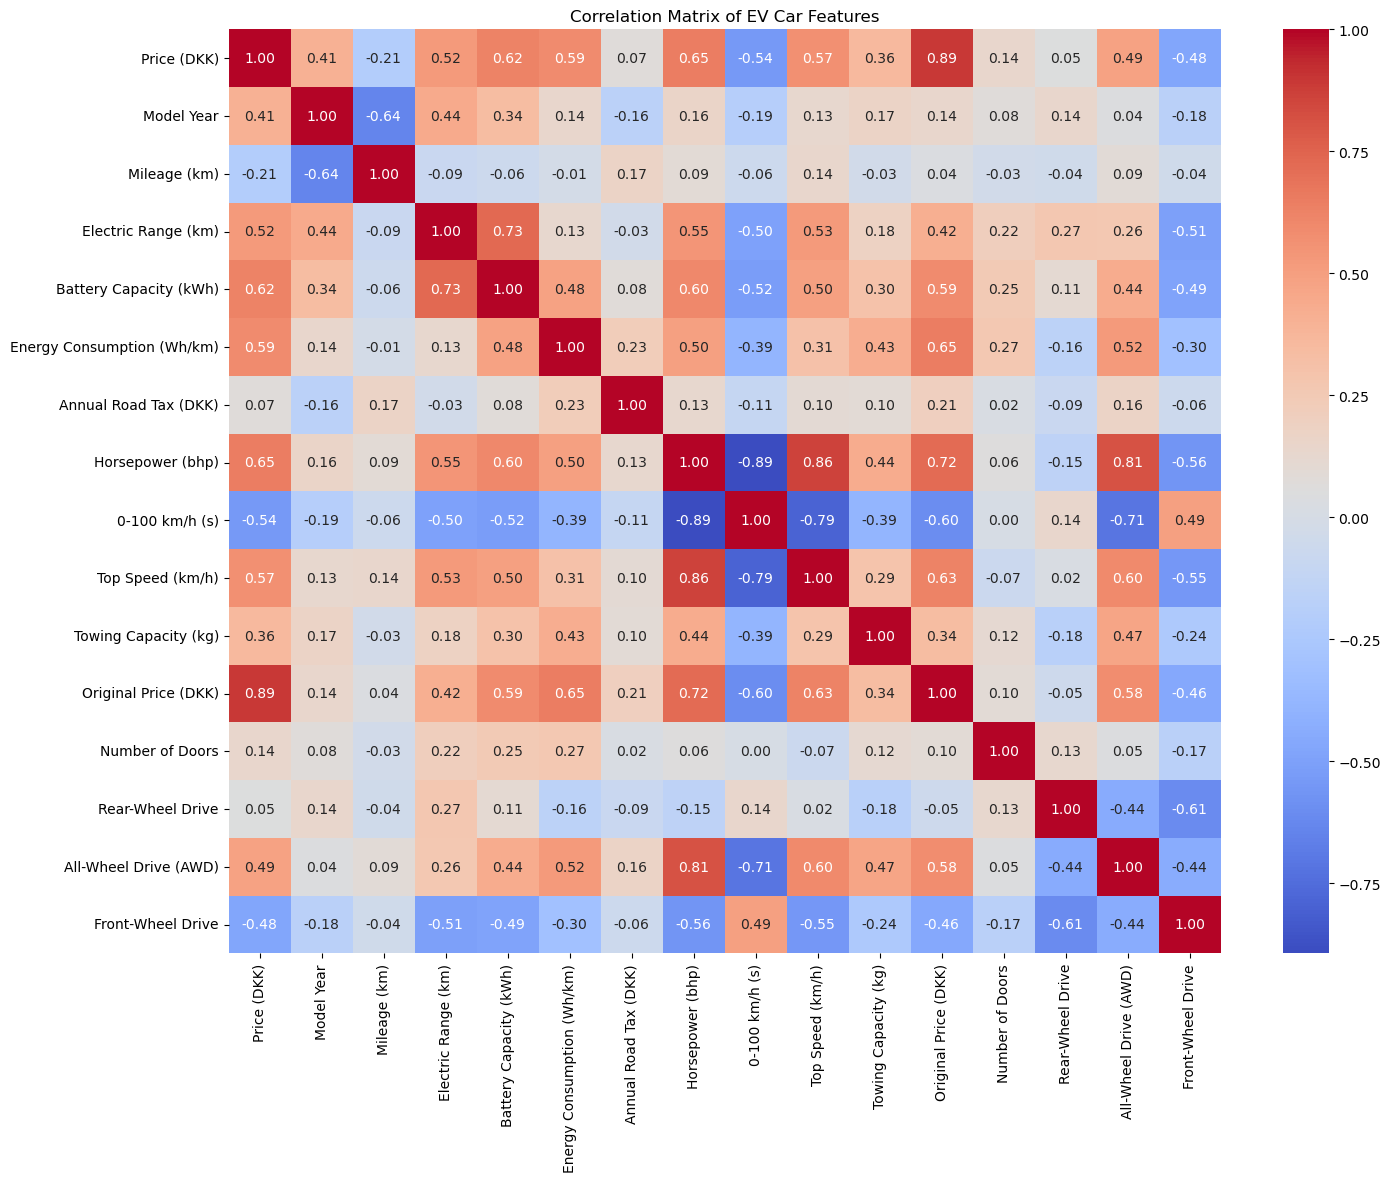

In [61]:
# Use this for Task 4. Add more code blocks if needed.

#Correlation matrix 

corr_matrix = df.corr()
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Matrix of EV Car Features')
plt.show()

In [62]:
#Ordinary least squares regression

ols_model = LinearRegression(fit_intercept=False)
ols_model.fit(X_train, y_train)

#Performance on training data
y_pred_ols_train = ols_model.predict(X_train)

mse_ols_train = mean_squared_error(y_train, y_pred_ols_train)
rmse_ols_train = np.sqrt(mse_ols_train)
r2_ols_train = r2_score(y_train, y_pred_ols_train)

print(f"OLS Training MSE: {mse_ols_train:.2f}")
print(f"OLS Training RMSE: {rmse_ols_train:.2f}")
print(f"OLS Training R^2: {r2_ols_train:.4f}")

#Performance on test data
y_pred_ols_test = ols_model.predict(X_test)

mse_ols_test = mean_squared_error(y_test, y_pred_ols_test)
rmse_ols_test = np.sqrt(mse_ols_test)
r2_ols_test = r2_score(y_test, y_pred_ols_test)

print(f"OLS Test MSE: {mse_ols_test:.2f}")
print(f"OLS Test RMSE: {rmse_ols_test:.2f}")
print(f"OLS Test R^2: {r2_ols_test:.4f}")


OLS Training MSE: 2202393429.56
OLS Training RMSE: 46929.66
OLS Training R^2: 0.9022
OLS Test MSE: 2619480911.29
OLS Test RMSE: 51180.86
OLS Test R^2: 0.8704


Commenting on test data, we can see that the RMSE is 51.180 DKK which is the amount the predictions will be off in the model. The model itself seems relatively weel fitted, with an R^2 of 0.87 explaining around 87% of th evariance in the prices of cars in the test set. 
This also shows that the prediction and calcualtions performed int he first part are coherent with this ones yilding similar resutls. 

### Task 5: Ridge, Lasso and Elastic Net
In order for Ridge and Lasso (and Elastic net) to have an effect, you must use scaled data to build the models, since regularization depends on coefficient magnitude, and if using non-scaled data the penalty will affect them unequally. Feel free to use this code to scale the data:

```python
# Standardize X
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

# Standardize y
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1)).flatten()
```
For the final task you must do the following
   - Ridge regression (using multiple alphas)
   - Lasso regression (using multiple alphas)
   - Elastic Net (using multiple alphas)
 - Discussion and conclusion:
   - Discuss the MSE and $R^2$ of all 3 models and conclude which model has the best performance - note the MSE will be scaled!
   - Rebuild the OLS model from Task 4, but this time use the scaled data from this task - interpret the meaning of the model's coefficients
   - Use the coefficients of the best ridge and lasso model to print the 5 most important features and compare to the 5 most important features in the OLS with scaled data model. Do the models agree about which features are the most important?

Note: You may get a convergence warning; try increasing the `max_iter` parameter of the model (the default is 1000 - maybe set it to 100000)

In [63]:
# Use this for Task 5. Add more code blocks if needed.

#Data scaling 

scaler_x = StandardScaler()
X_train_scaled = scaler_x.fit_transform(X_train)
X_test_scaled = scaler_x.transform(X_test)

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).flatten()
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1)).flatten()

#Run the models with different alphas
alphas = [0.001, 0.01, 0.1, 1, 10, 100]
results = {}

print("Ridge Regression Results:")
best_ridge_score = -1
best_ridge_alpha = None
for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_scaled, y_train_scaled)
    y_pred_ridge = ridge.predict(X_test_scaled)
    mse = mean_squared_error(y_test_scaled, y_pred_ridge)
    r2 = r2_score(y_test_scaled, y_pred_ridge)
    print(f"Alpha: {alpha:<5} -> Scaled MSE: {mse:.4f}, R^2: {r2:.4f}")
    if r2 > best_ridge_score:
        best_ridge_score = r2
        best_ridge_alpha = alpha

Ridge Regression Results:
Alpha: 0.001 -> Scaled MSE: 0.1164, R^2: 0.8704
Alpha: 0.01  -> Scaled MSE: 0.1164, R^2: 0.8704
Alpha: 0.1   -> Scaled MSE: 0.1164, R^2: 0.8704
Alpha: 1     -> Scaled MSE: 0.1164, R^2: 0.8704
Alpha: 10    -> Scaled MSE: 0.1166, R^2: 0.8702
Alpha: 100   -> Scaled MSE: 0.1188, R^2: 0.8677


In [64]:
print ("Lasso Regression Results:")
best_lasso_score = -1
best_lasso_alpha = None
for alpha in alphas:
    lasso = Lasso(alpha=alpha)
    lasso.fit(X_train_scaled, y_train_scaled)
    y_pred_lasso = lasso.predict(X_test_scaled)
    mse = mean_squared_error(y_test_scaled, y_pred_lasso)
    r2 = r2_score(y_test_scaled, y_pred_lasso)
    print(f"Alpha: {alpha:<5} -> Scaled MSE: {mse:.4f}, R^2: {r2:.4f}")
    if r2 > best_lasso_score:
        best_lasso_score = r2
        best_lasso_alpha = alpha


Lasso Regression Results:
Alpha: 0.001 -> Scaled MSE: 0.1143, R^2: 0.8727
Alpha: 0.01  -> Scaled MSE: 0.1120, R^2: 0.8753
Alpha: 0.1   -> Scaled MSE: 0.1346, R^2: 0.8502
Alpha: 1     -> Scaled MSE: 0.8982, R^2: -0.0001
Alpha: 10    -> Scaled MSE: 0.8982, R^2: -0.0001
Alpha: 100   -> Scaled MSE: 0.8982, R^2: -0.0001


In [65]:
print("\n--- Elastic Net Results ---")
for alpha in alphas:
    # Increased max_iter to prevent convergence warnings
    elastic_net = ElasticNet(alpha=alpha, max_iter=100000)
    elastic_net.fit(X_train_scaled, y_train_scaled)
    y_pred_en = elastic_net.predict(X_test_scaled)
    mse = mean_squared_error(y_test_scaled, y_pred_en)
    r2 = r2_score(y_test_scaled, y_pred_en)
    print(f"Alpha: {alpha:<5} -> Scaled MSE: {mse:.4f}, R^2: {r2:.4f}")


--- Elastic Net Results ---
Alpha: 0.001 -> Scaled MSE: 0.1154, R^2: 0.8715
Alpha: 0.01  -> Scaled MSE: 0.1137, R^2: 0.8734
Alpha: 0.1   -> Scaled MSE: 0.1367, R^2: 0.8478
Alpha: 1     -> Scaled MSE: 0.5201, R^2: 0.4209
Alpha: 10    -> Scaled MSE: 0.8982, R^2: -0.0001
Alpha: 100   -> Scaled MSE: 0.8982, R^2: -0.0001


All models seem to have a very similar performance at around 0.87 in their best. It is interesting that despite the lasso model being the one that usually simplifies the model, it gets similar performance. 

In [66]:
#Resbuilt model OLS but scaled

ols_model_scaled = LinearRegression(fit_intercept=False)
ols_model_scaled.fit(X_train_scaled, y_train_scaled)
y_pred_ols_scaled = ols_model_scaled.predict(X_test_scaled)
mse_ols_scaled = mean_squared_error(y_test_scaled, y_pred_ols_scaled)
rmse_ols_scaled = np.sqrt(mse_ols_scaled)
r2_ols_scaled = r2_score(y_test_scaled, y_pred_ols_scaled)
print(f"OLS Scaled Test MSE: {mse_ols_scaled:.4f}")
print(f"OLS Scaled Test RMSE: {rmse_ols_scaled:.4f}")
print(f"OLS Scaled Test R^2: {r2_ols_scaled:.4f}")

OLS Scaled Test MSE: 0.1164
OLS Scaled Test RMSE: 0.3411
OLS Scaled Test R^2: 0.8704


Each coefficient represents the change in the target variable, measured in standard deviations, for a one standard deviation increase in the corresponding feature, assuming all other features are held constant.This means that Bbcause all features are on the same scale, we can directly compare the magnitude (absolute value) of their coefficients to gauge their relative importance in predicting the car price. Now we cannot see the price error but we can easily compare the coeficients of all features. 

In [67]:
def print_top_features(model, model_name):
    # Create a pandas series of features and their coefficients
    coefs = pd.Series(model.coef_, index=X_train.columns)
    # Get the absolute values and sort them
    imp_coefs = abs(coefs).sort_values(ascending=False)
    print(f"\nTop 5 most important features for {model_name}:")
    print(imp_coefs.head(5))

print_top_features(ols_model_scaled, "Scaled OLS")

best_ridge_model = Ridge(alpha=best_ridge_alpha).fit(X_train_scaled, y_train_scaled)
print_top_features(best_ridge_model, f"Ridge (alpha={best_ridge_alpha})")

best_lasso_model = Lasso(alpha=best_lasso_alpha).fit(X_train_scaled, y_train_scaled)
print_top_features(best_lasso_model, f"Lasso (alpha={best_lasso_alpha})")






Top 5 most important features for Scaled OLS:
Original Price (DKK)      0.845988
Model Year                0.168133
Mileage (km)              0.102812
0-100 km/h (s)            0.081373
Battery Capacity (kWh)    0.077270
dtype: float64

Top 5 most important features for Ridge (alpha=0.001):
Original Price (DKK)      0.845987
Model Year                0.168133
Mileage (km)              0.102812
0-100 km/h (s)            0.081373
Battery Capacity (kWh)    0.077270
dtype: float64

Top 5 most important features for Lasso (alpha=0.01):
Original Price (DKK)      0.832317
Model Year                0.167293
Mileage (km)              0.094031
Battery Capacity (kWh)    0.060898
Annual Road Tax (DKK)     0.050535
dtype: float64


The 5 top features of OLS and Ridge are identical, this makens sense becase the best ridge model uses a small alph which applies a small penalty, making the model behave similarly to an OLS. 

Lasso on the other hand droped the 0-100 Km/h feature, and added the annual road tax. This is because lasso performs automatic feature selection. The penalty applied by the model was strong enough to skrink the coefficient of the 0-100 km/h more than the one from the Annual Road Tax. 